<a href="https://colab.research.google.com/github/NeoByteVoyager/DeepLearning/blob/main/Notes/Transformer/Various_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Background


## Self-Attention 时间复杂度

设输入：

$$
X \in R^{n \times d}
$$

其中：

- $n$：序列长度（token 数量）
- $d$：embedding 维度

---

### 总时间复杂度

综合：

$$
O(nd^2)+O(n^2d)+O(n^2d)
$$

通常简化为：

$$
\boxed{O(nd^2+n^2d)}
$$

当序列较长时：

$$
\boxed{O(n^2d)}
$$

其中：

- $nd^2$ 来自 Q、K、V 投影
- $n^2d$ 来自 token 两两之间的注意力计算

## Notes

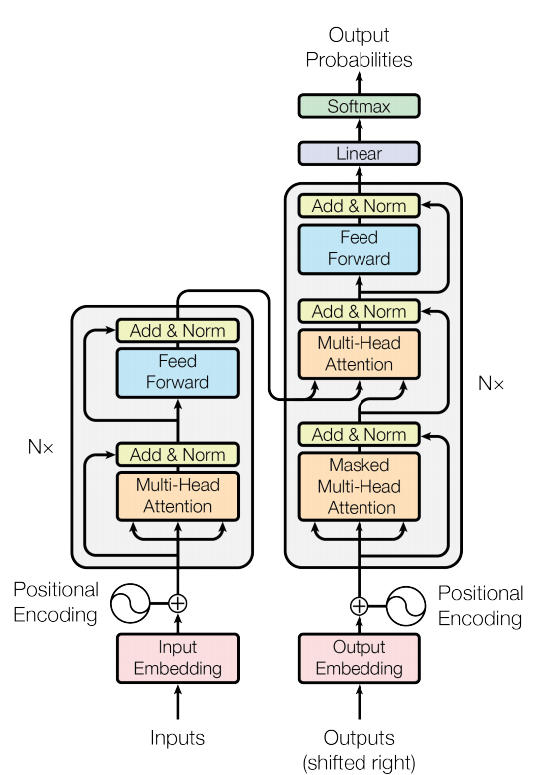

- Self attention dominates compution **when $N$ is large.**

# Skip some calculation with human knowledge

## 1.Local attention/Truncated attention

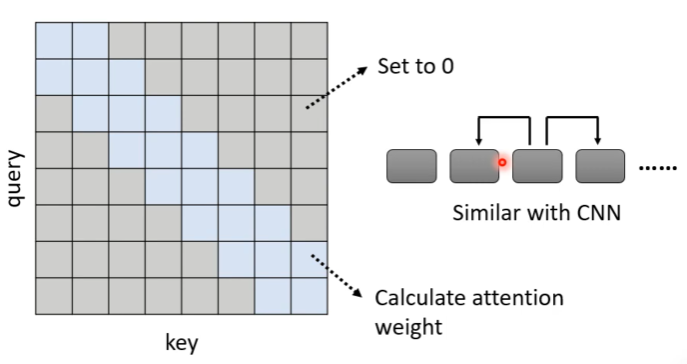

- Don't calculate all attention map, **only calculate some attention score** according to the understanding of the problem.(Similar to CNN)


## 2.Stride attention


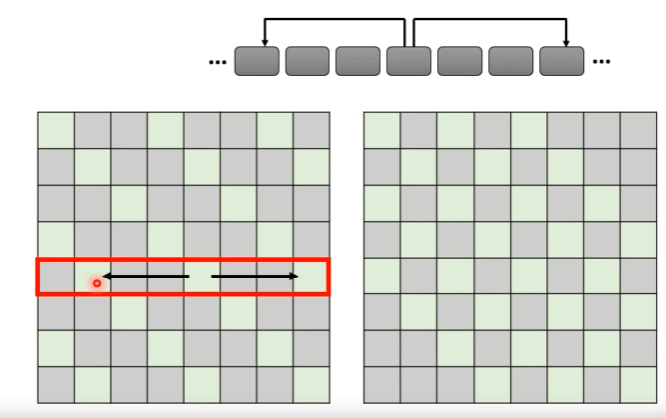

- Skip stride - 1 tokens

## 3.Global attention


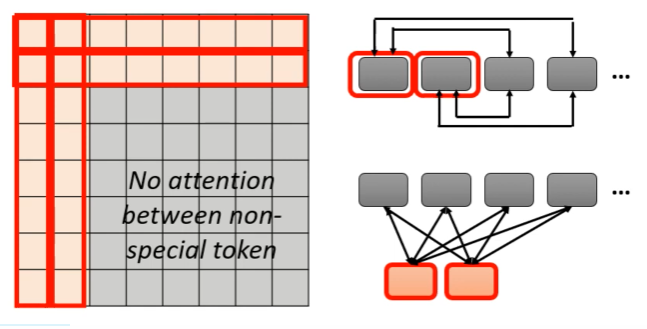

Add **special token** into original sequence
- Attend to every token → collect **global information**
- Attended by every token → spread **global information**

# Focus on critical parts

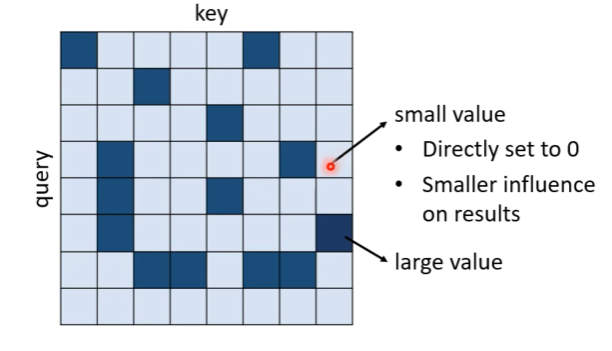

Set to 0 which has **small similarity.**

## 1.Cluster

### step 1

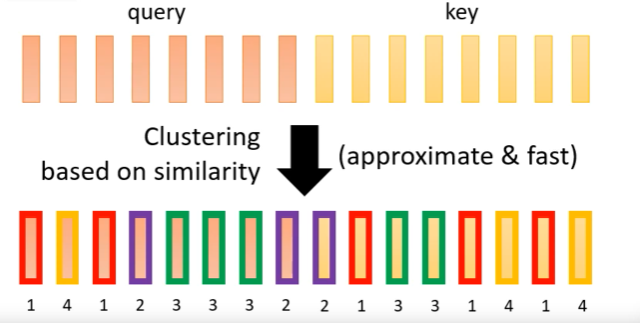

- Cluster is like block
- The similar vector is in the same cluster

### step 2


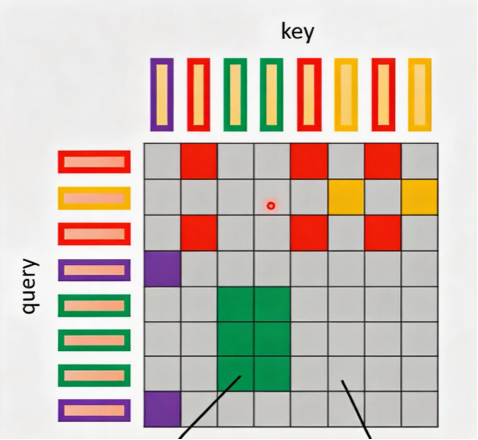

- Calculate the attention when they are in the same cluster


## 2.Learnable Patterns

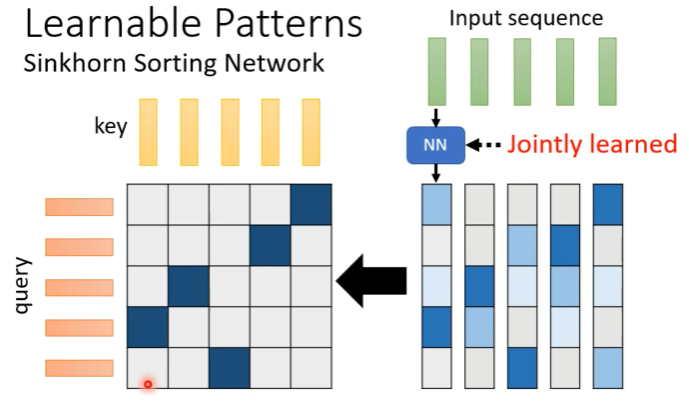

- The attention should be skipped or not **decided by another learned module**

# Abandon full attention matrix

### Pick out **some representative keys and values**





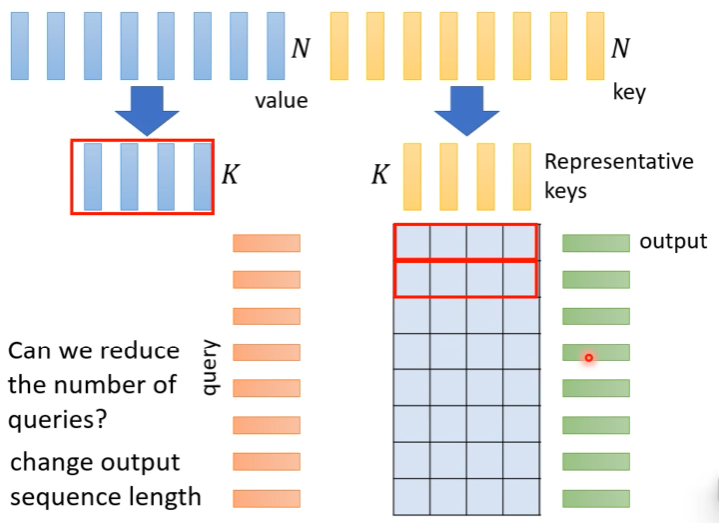

### Reduce numbers of keys

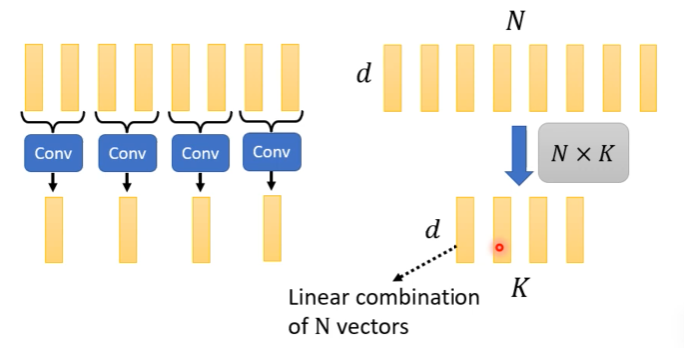

- Compressed by **convolution layer**
- Compressed by **multiplying a matrix**

# Attention Mechanism is **three-matrix multiplication**

## Change **the order of calculation**

##

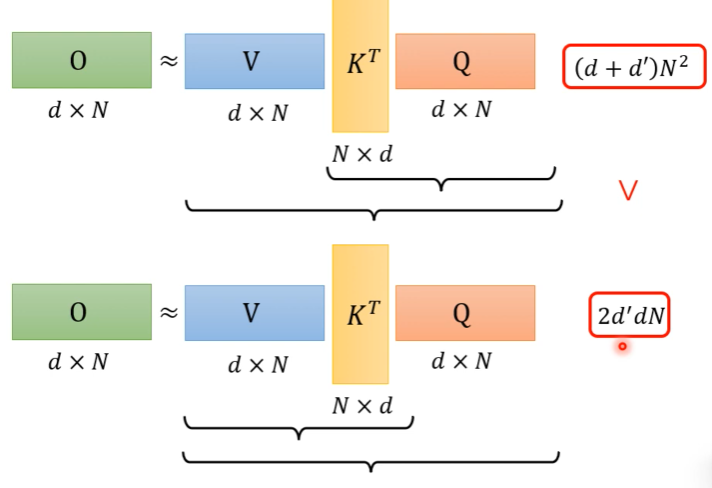

- The complexity reduced effectively.
- This lack softmax function

## Softmax Attention



$$
b^1=\sum_{i=1}^{N}\alpha'_{1,i}v^i
$$

其中：

$$
\alpha'_{1,i}
=
\frac{\exp(q^1\cdot k^i)}
{\sum_{j=1}^{N}\exp(q^1\cdot k^j)}
$$

因此：

$$
b^1
=
\sum_{i=1}^{N}
\frac{\exp(q^1\cdot k^i)}
{\sum_{j=1}^{N}\exp(q^1\cdot k^j)}
v^i
$$


---

## Kernel Trick 近似

将：

$$
\exp(q\cdot k)
$$

近似为：

$$
\exp(q\cdot k)\approx \phi(q)\cdot\phi(k)
$$

得到：

$$
b^1
=
\sum_{i=1}^{N}
\frac{\phi(q^1)\cdot\phi(k^i)}
{\sum_{j=1}^{N}\phi(q^1)\cdot\phi(k^j)}
v^i
$$


---

## 提取公共项

分子：

$$
\sum_{i=1}^{N}
[\phi(q^1)\cdot\phi(k^i)]v^i
$$


分母：

$$
\sum_{j=1}^{N}
\phi(q^1)\cdot\phi(k^j)
$$


由于：

$$
\phi(q^1)
$$

对于所有 $j$ 都相同，可以提出：

$$
\sum_{j=1}^{N}
\phi(q^1)\cdot\phi(k^j)
=
\phi(q^1)\cdot
\sum_{j=1}^{N}\phi(k^j)
$$


所以：

$$
b^1
=
\frac{
\sum_{i=1}^{N}
[\phi(q^1)\cdot\phi(k^i)]v^i
}
{
\phi(q^1)\cdot
\sum_{j=1}^{N}\phi(k^j)
}
$$


---

## 交换计算顺序

原始 Attention：

$$
\sum_i
(\phi(q^1)\cdot\phi(k^i))v^i
$$


展开：

$$
=
[\phi(q^1)\cdot\phi(k^1)]v^1
+
[\phi(q^1)\cdot\phi(k^2)]v^2
+\cdots
$$


展开点积：

$$
=
(q_1^1k_1^1+q_2^1k_2^1+\cdots)
v^1
+
(q_1^1k_1^2+q_2^1k_2^2+\cdots)
v^2
+\cdots
$$


进一步展开：

$$
=
q_1^1k_1^1v^1
+
q_2^1k_2^1v^1
+\cdots
+
q_1^1k_1^2v^2
+
q_2^1k_2^2v^2
+\cdots
$$


重新组合：

$$
=
q_1^1(k_1^1v^1+k_1^2v^2+\cdots)
+
q_2^1(k_2^1v^1+k_2^2v^2+\cdots)
+\cdots
$$




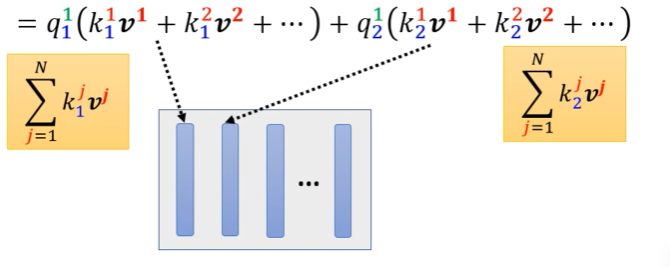

## 矩阵形式

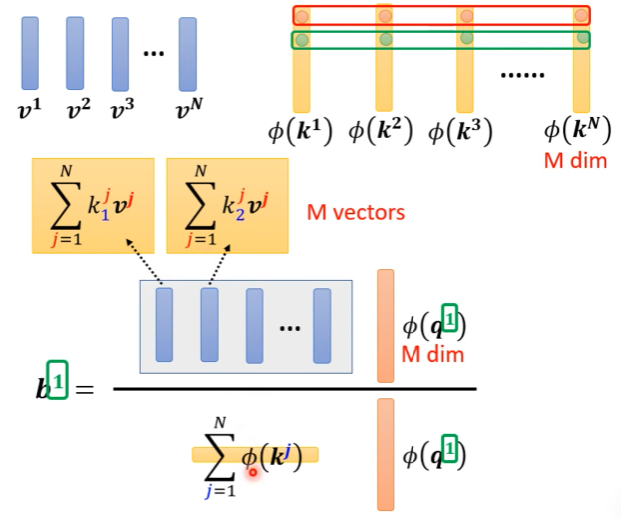

## Apply to attention calculation

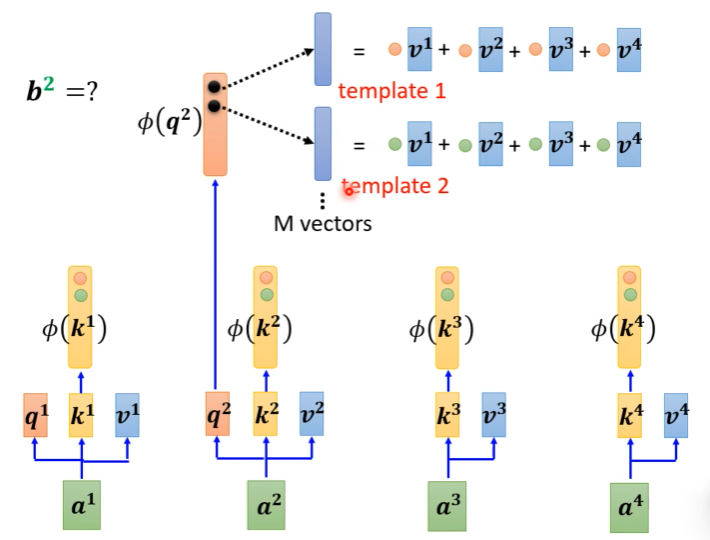

**Calculation explanation:**
1. Generate templates by **the linear combination of value vector**
2. Generate output by **the linear combination of templates**